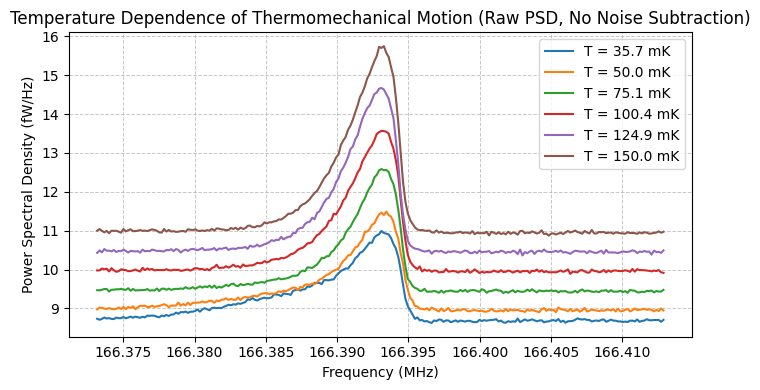

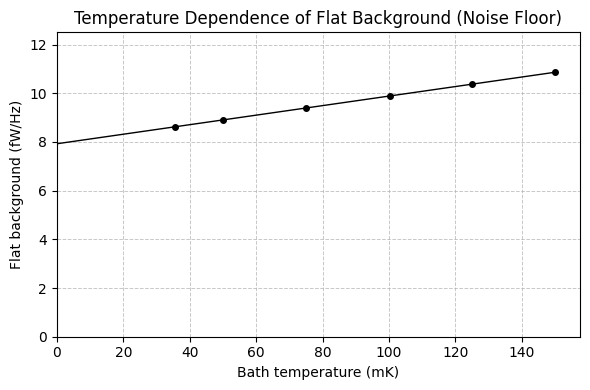

In [3]:
# Raw PSD - no noise subtraction
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qcodes as qc


run_ids = [1263, 1265, 1267, 1299, 1303, 1305, 1309, 1311, 1313, 1315,
           1319, 1321, 1323, 1325, 1329, 1331, 1333, 1335, 1339, 1341, 1343, 1345]

temperatures = [35.6766, 35.6766, 35.6766,
                50.0152, 50.0152, 50.0152,
                75.0531, 75.0531, 75.0531, 75.0531,
                100.3800, 100.3800, 100.3800, 100.3800,
                124.8840, 124.8840, 124.8840, 124.8840,
                149.9940, 149.9940, 149.9940, 149.9940]

qc.config["core"]["db_location"] = r"D:\databases CD11_D7_C1\CD11_D7_C1_part3.db"


def extract_1d(run_id,
               data_1d_name="Resistance",
               setpoint_name="single_gate",
               plot=False):
    ds       = qc.load_by_id(run_id)
    par_data = ds.get_parameter_data(data_1d_name)
    freq_raw = par_data[data_1d_name][setpoint_name]
    df_dict  = ds.to_pandas_dataframe_dict()
    psd_raw  = df_dict[data_1d_name]

    freq = np.asarray(freq_raw).flatten()
    psd  = np.asarray(psd_raw).flatten()

    if plot:
        plt.plot(freq, psd)
        plt.title(f"Measurement {run_id}")
        plt.ylabel("Avg PSD (W/Hz)")
        plt.xlabel("Frequency (MHz)")
        plt.show()

    return freq, psd


temp_data       = {}
frequency_array = None

for run_id, temp in zip(run_ids, temperatures):
    freq, psd = extract_1d(run_id,
                           data_1d_name="avg_avg_psd_nodrive",
                           setpoint_name="freq_param",
                           plot=False)
    if frequency_array is None:
        frequency_array = freq
    temp_data.setdefault(temp, []).append(psd)


# --- Plot 1: Raw PSD per temperature ---
plt.figure(figsize=(7, 4))

noise_by_temp = {}  # store noise floor for Plot 2

for temp in sorted(temp_data.keys()):
    traces  = np.vstack(temp_data[temp])
    avg_psd = traces.mean(axis=0)

    noise_by_temp[temp] = avg_psd.min()

    plt.ticklabel_format(axis='x', style='plain', useOffset=False)
    plt.ticklabel_format(axis='y', style='plain', useOffset=False)
    plt.plot(frequency_array * 1e-6, avg_psd * 1e15,
             label=f"T = {temp:.1f} mK")

plt.ticklabel_format(axis='x', style='plain', useOffset=False)
plt.ticklabel_format(axis='y', style='plain', useOffset=False)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power Spectral Density (fW/Hz)")
plt.title("Temperature Dependence of Thermomechanical Motion (Raw PSD, No Noise Subtraction)")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()


# --- Plot 2: Flat background (noise floor) vs temperature ---
temps_sorted   = sorted(noise_by_temp.keys())
noise_levels   = np.array([noise_by_temp[t] for t in temps_sorted])

plt.figure(figsize=(6, 4))
# Extrapolate line to y-axis via linear fit
fit_coeffs = np.polyfit(temps_sorted, noise_levels * 1e15, 1)
fit_fn = np.poly1d(fit_coeffs)
fit_x = np.linspace(0, max(temps_sorted), 200)
plt.plot(fit_x, fit_fn(fit_x), "k-", linewidth=1)
plt.plot(temps_sorted, noise_levels * 1e15, "k.", markersize=8)
plt.xlabel("Bath temperature (mK)")
plt.ylabel("Flat background (fW/Hz)")
plt.title("Temperature Dependence of Flat Background (Noise Floor)")
plt.xlim(0, max(temps_sorted) * 1.05)
plt.ylim(0, max(noise_levels * 1e15) * 1.15)
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()
